# Rejection ABC for Adaptive-Network SIR Model

This notebook implements rejection ABC to infer (β, γ, ρ) from observed epidemic data, 
and investigates the effects of summary statistic subsets, distance metrics, and 
acceptance tolerance on posterior quality.

## Notebook Structure

 1. Setup & Data Loading
 2. Summary Statistics (three nested subsets)
 3. Observed Summaries
 4. Normalization (pilot simulations for z-score scaling)
 5. Distance Functions (Euclidean, Manhattan)
 6. Rejection ABC Engine
 7. Visualization Functions
 8. Experiment 1: Summary statistic subsets
 9. Experiment 2: Distance metric comparison
10. Experiment 3: Acceptance tolerance
11. Posterior Predictive Check
12. Interface for Advanced Methods

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from simulator import simulate
from time import time
import csv, os

# Reproducibility
SEED = 42

# Plot style
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


## 1. Load Observed Data

The observed data consists of 40 replicates generated with the same unknown (β, γ, ρ):
- **infected_timeseries.csv**: infected fraction at each of 201 time steps
- **rewiring_timeseries.csv**: rewire count at each of 201 time steps  
- **final_degree_histograms.csv**: node degree counts (0-30) at t=200

In [10]:
def load_observed_data(data_dir="data"):
    """Load the three observed CSV data files.
    
    Returns
    -------
    infected : dict, replicate_id -> np.array of shape (201,)
    rewiring : dict, replicate_id -> np.array of shape (201,)
    degree   : dict, replicate_id -> np.array of shape (31,)
    """
    
    def read_csv(path):
        with open(path) as f:
            return list(csv.DictReader(f))
    
    # Infected time series
    rows = read_csv(os.path.join(data_dir, "infected_timeseries.csv"))
    infected = {}
    for row in rows:
        rid, t = int(row["replicate_id"]), int(row["time"])
        if rid not in infected:
            infected[rid] = np.zeros(201)
        infected[rid][t] = float(row["infected_fraction"])
    
    # Rewiring time series
    rows = read_csv(os.path.join(data_dir, "rewiring_timeseries.csv"))
    rewiring = {}
    for row in rows:
        rid, t = int(row["replicate_id"]), int(row["time"])
        if rid not in rewiring:
            rewiring[rid] = np.zeros(201)
        rewiring[rid][t] = int(row["rewire_count"])
    
    # Final degree histograms
    rows = read_csv(os.path.join(data_dir, "final_degree_histograms.csv"))
    degree = {}
    for row in rows:
        rid, d = int(row["replicate_id"]), int(row["degree"])
        if rid not in degree:
            degree[rid] = np.zeros(31)
        degree[rid][d] = int(row["count"])
    
    return infected, rewiring, degree


obs_infected, obs_rewiring, obs_degree = load_observed_data("data")

N_REPLICATES = len(obs_infected)
print(f"Loaded {N_REPLICATES} replicates")
print(f"Infection series shape: {obs_infected[0].shape}")
print(f"Rewiring series shape:  {obs_rewiring[0].shape}")
print(f"Degree histogram shape: {obs_degree[0].shape}")


Loaded 40 replicates
Infection series shape: (201,)
Rewiring series shape:  (201,)
Degree histogram shape: (31,)


## 2. Summary Statistics

We define three nested subsets of summary statistics:

| Subset | Statistics | Dimension |
|--------|-----------|-----------|
| **Subset 1** (epidemic only) | peak fraction, time to peak, half-life | 3 |
| **Subset 2** (+ rewiring) | above + rewiring peak count, rewiring time to peak | 5 |
| **Subset 3** (+ network) | above + degree variance | 6 |

Each function extracts summaries from a single replicate.  
We then average across all 40 replicates to get the final summary vector.


In [11]:
def compute_summaries_single(infected_curve, rewiring_curve, degree_histogram, subset=3):
    """Compute summary statistics from a single replicate.
    
    Parameters
    ----------
    infected_curve    : np.array, shape (201,)
    rewiring_curve    : np.array, shape (201,)
    degree_histogram  : np.array, shape (31,)
    subset            : int, one of {1, 2, 3}
    
    Returns
    -------
    np.array of summary statistics
    """
    stats = []
    
    # --- Subset 1: Epidemic summaries ---
    
    # Peak infected fraction
    peak_frac = np.max(infected_curve)
    stats.append(peak_frac)
    
    # Time to peak
    time_to_peak = np.argmax(infected_curve)
    stats.append(time_to_peak)
    
    # Half-life: days after peak until infected fraction drops below half of peak
    if peak_frac > 0:
        post_peak = infected_curve[time_to_peak:]
        below_half = np.where(post_peak < peak_frac / 2)[0]
        half_life = below_half[0] if len(below_half) > 0 else len(post_peak)
    else:
        half_life = 0
    stats.append(half_life)
    
    if subset >= 2:
        # --- Subset 2: Rewiring summaries ---
        peak_rewire = np.max(rewiring_curve)
        stats.append(peak_rewire)
        
        time_to_peak_rewire = np.argmax(rewiring_curve)
        stats.append(time_to_peak_rewire)
    
    if subset >= 3:
        # --- Subset 3: Network structure ---
        degrees = np.arange(31)
        total_nodes = np.sum(degree_histogram)
        if total_nodes > 0:
            mean_deg = np.dot(degrees, degree_histogram) / total_nodes
            var_deg = np.dot((degrees - mean_deg)**2, degree_histogram) / total_nodes
        else:
            var_deg = 0.0
        stats.append(var_deg)
    
    return np.array(stats, dtype=np.float64)


def compute_summaries_averaged(infected_dict, rewiring_dict, degree_dict, subset=3):
    """Compute summary statistics averaged across all replicates.
    
    Averaging reduces stochastic noise and gives a stable target 
    for the ABC distance computation.
    """
    all_stats = []
    for rid in sorted(infected_dict.keys()):
        s = compute_summaries_single(
            infected_dict[rid], rewiring_dict[rid], degree_dict[rid], subset=subset
        )
        all_stats.append(s)
    return np.mean(all_stats, axis=0)


# Labels for plotting and display
SUMMARY_LABELS = {
    1: ["Peak fraction", "Time to peak", "Half-life"],
    2: ["Peak fraction", "Time to peak", "Half-life", 
        "Peak rewire count", "Rewire time to peak"],
    3: ["Peak fraction", "Time to peak", "Half-life",
        "Peak rewire count", "Rewire time to peak", "Degree variance"],
}


## 3. Compute Observed Summaries

Compute the target summary vector from the observed data for each subset.


In [12]:
obs_summaries = {}
for subset in [1, 2, 3]:
    obs_summaries[subset] = compute_summaries_averaged(
        obs_infected, obs_rewiring, obs_degree, subset=subset
    )
    print(f"\nSubset {subset} observed summaries:")
    for label, val in zip(SUMMARY_LABELS[subset], obs_summaries[subset]):
        print(f"  {label:25s} = {val:.4f}")



Subset 1 observed summaries:
  Peak fraction             = 0.6571
  Time to peak              = 8.7500
  Half-life                 = 10.1250

Subset 2 observed summaries:
  Peak fraction             = 0.6571
  Time to peak              = 8.7500
  Half-life                 = 10.1250
  Peak rewire count         = 98.1250
  Rewire time to peak       = 5.5000

Subset 3 observed summaries:
  Peak fraction             = 0.6571
  Time to peak              = 8.7500
  Half-life                 = 10.1250
  Peak rewire count         = 98.1250
  Rewire time to peak       = 5.5000
  Degree variance           = 10.3410


## 4. Pilot Simulations & Normalization

Summary statistics have wildly different scales (e.g. peak fraction ∈ [0, 1] 
vs peak rewire count ∈ [0, 500]). Without normalization, large-scale statistics 
dominate the distance and small-scale ones are effectively ignored.

We run pilot simulations from the prior to estimate the mean and standard 
deviation of each summary, then z-score normalize before computing distances.


In [13]:
def draw_from_prior(rng):
    """Sample (beta, gamma, rho) from the prior distributions."""
    beta  = rng.uniform(0.05, 0.50)
    gamma = rng.uniform(0.02, 0.20)
    rho   = rng.uniform(0.00, 0.80)
    return beta, gamma, rho


def run_pilot_simulations(n_pilot=500, n_reps=40, subset=3, seed=123):
    """Run pilot simulations from the prior to estimate normalization constants.
    
    Parameters
    ----------
    n_pilot  : int, number of prior draws
    n_reps   : int, replicates per draw 
    subset   : int, summary subset
    seed     : int
    
    Returns
    -------
    pilot_summaries : np.array, shape (n_pilot, n_stats)
    pilot_params    : np.array, shape (n_pilot, 3)
    norm_mean       : np.array, shape (n_stats,)
    norm_std        : np.array, shape (n_stats,)
    """
    rng = np.random.default_rng(seed)
    
    pilot_summaries = []
    pilot_params = []

    for i in range(n_pilot):
        beta, gamma, rho = draw_from_prior(rng)
        
        inf_dict, rew_dict, deg_dict = {}, {}, {}
        for r in range(n_reps):
            inf, rew, deg = simulate(beta, gamma, rho, rng=rng)
            inf_dict[r] = inf
            rew_dict[r] = rew
            deg_dict[r] = deg
        
        s = compute_summaries_averaged(inf_dict, rew_dict, deg_dict, subset=subset)
        pilot_summaries.append(s)
        pilot_params.append([beta, gamma, rho])

        if (i + 1) % 100 == 0:
            print(f"Pilot {i+1}/{n_pilot}")
    
    pilot_summaries = np.array(pilot_summaries)
    pilot_params = np.array(pilot_params)
    
    norm_mean = np.mean(pilot_summaries, axis=0)
    norm_std = np.std(pilot_summaries, axis=0)
    norm_std[norm_std < 1e-10] = 1.0  # guard against zero std
    
    print(f"\nNormalization constants:")
    for label, m, s in zip(SUMMARY_LABELS[subset], norm_mean, norm_std):
        print(f"  {label:25s}  mean={m:.4f}  std={s:.4f}")
    
    return pilot_summaries, pilot_params, norm_mean, norm_std


# Run pilot for subset 3 (then obtain subset 1,2 through slicing in next step)
pilot_summaries, pilot_params, norm_mean_full, norm_std_full = run_pilot_simulations(
    n_pilot=500, n_reps=40, subset=3, seed=123
)

# Normalization constants per subset (slices of the full set)
norm_constants = {
    1: (norm_mean_full[:3], norm_std_full[:3]),
    2: (norm_mean_full[:5], norm_std_full[:5]),
    3: (norm_mean_full[:6], norm_std_full[:6]),
}

Pilot 100/500
Pilot 200/500
Pilot 300/500
Pilot 400/500
Pilot 500/500

Normalization constants:
  Peak fraction              mean=0.5864  std=0.2529
  Time to peak               mean=6.7246  std=3.6079
  Half-life                  mean=10.4379  std=6.2985
  Peak rewire count          mean=104.3357  std=65.0272
  Rewire time to peak        mean=4.1609  std=2.7379
  Degree variance            mean=11.5634  std=2.7461


## 5. Distance Functions

Two distance metrics on z-score normalized summaries:

1. **Euclidean (L2)**: standard choice, penalizes large deviations heavily  
2. **Manhattan (L1)**: more robust to outliers in individual summaries


In [14]:
def distance_euclidean(s_sim, s_obs, norm_mean, norm_std):
    """Normalized Euclidean (L2) distance."""
    z_sim = (s_sim - norm_mean) / norm_std
    z_obs = (s_obs - norm_mean) / norm_std
    return np.sqrt(np.sum((z_sim - z_obs)**2))


def distance_manhattan(s_sim, s_obs, norm_mean, norm_std):
    """Normalized Manhattan (L1) distance."""
    z_sim = (s_sim - norm_mean) / norm_std
    z_obs = (s_obs - norm_mean) / norm_std
    return np.sum(np.abs(z_sim - z_obs))


DISTANCE_FUNCTIONS = {
    "euclidean": distance_euclidean,
    "manhattan": distance_manhattan,
}

## 6. Rejection ABC

The core algorithm:
1. Draw (β, γ, ρ) from the prior
2. Simulate replicates → compute averaged summary statistics
3. Compute distance to observed summaries
4. Store all (parameters, distance) pairs
5. Accept the top `accept_pct`% closest simulations

Rather than fixing a tolerance ε, we accept the top k% of simulations 
by distance, which guarantees a usable sample size.

All parameters and distances are stored so that different acceptance 
thresholds can be tested without re-simulating (see Experiment 3).


In [15]:
def rejection_abc(obs_summary, norm_mean, norm_std, 
                  n_simulations=10000, n_reps_per_sim=40, subset=3,
                  distance_name="euclidean", accept_pct=1.0, seed=42):
    """Run rejection ABC.
    
    Parameters
    ----------
    obs_summary     : np.array, target observed summaries
    norm_mean       : np.array, normalization means from pilot
    norm_std        : np.array, normalization stds from pilot
    n_simulations   : int, total prior draws
    n_reps_per_sim  : int, replicates per draw
    subset          : int, which summary subset (1, 2, or 3)
    distance_name   : str, "euclidean" or "manhattan"
    accept_pct      : float, top percentage to accept
    seed            : int, random seed
    
    Returns
    -------
    dict with keys:
        all_params       : np.array (n_simulations, 3)
        all_distances    : np.array (n_simulations,)
        all_summaries    : np.array (n_simulations, n_stats)
        accepted_params  : np.array (n_accepted, 3)
        accepted_dists   : np.array (n_accepted,)
        threshold        : float, effective tolerance
    """
    rng = np.random.default_rng(seed)
    dist_fn = DISTANCE_FUNCTIONS[distance_name]
    n_stats = len(obs_summary)
    
    all_params = np.zeros((n_simulations, 3))
    all_distances = np.zeros(n_simulations)
    all_summaries = np.zeros((n_simulations, n_stats))
    
    for i in range(n_simulations):
        beta, gamma, rho = draw_from_prior(rng)
        all_params[i] = [beta, gamma, rho]
        
        # Simulate replicates and compute averaged summaries
        inf_dict, rew_dict, deg_dict = {}, {}, {}
        for r in range(n_reps_per_sim):
            inf, rew, deg = simulate(beta, gamma, rho, rng=rng)
            inf_dict[r] = inf
            rew_dict[r] = rew
            deg_dict[r] = deg
        
        s_sim = compute_summaries_averaged(inf_dict, rew_dict, deg_dict, subset=subset)
        all_summaries[i] = s_sim
        all_distances[i] = dist_fn(s_sim, obs_summary, norm_mean, norm_std)
        
        if (i + 1) % 1000 == 0:
            print(f"Sim {i+1}/{n_simulations}")
    
    # Accept top accept_pct%
    n_accept = max(1, int(n_simulations * accept_pct / 100))
    sorted_idx = np.argsort(all_distances)
    accepted_idx = sorted_idx[:n_accept]
    
    print(f"\nTotal simulations: {n_simulations}")
    print(f"Accepted: {n_accept} ({accept_pct}%)")
    print(f"Effective tolerance: {all_distances[accepted_idx[-1]]:.4f}")
    print(f"Distance range: [{all_distances[accepted_idx[0]]:.4f}, "
          f"{all_distances[accepted_idx[-1]]:.4f}]")
    
    return {
        "all_params": all_params,
        "all_distances": all_distances,
        "all_summaries": all_summaries,
        "accepted_params": all_params[accepted_idx],
        "accepted_dists": all_distances[accepted_idx],
        "threshold": all_distances[accepted_idx[-1]],
    }


## 7. Visualization Functions

Standard plots for ABC posterior analysis:
- **Marginal histograms**: posterior density for each parameter vs the prior
- **Pairwise scatter plots**: reveals correlations and confounds between parameters
- **Posterior predictive check**: simulate from posterior, overlay on observed data


In [16]:
PARAM_NAMES = [r"β", r"γ", r"ρ"]
PRIOR_BOUNDS = [(0.05, 0.50), (0.02, 0.20), (0.0, 0.80)]


def plot_marginals(accepted_params, title=""):
    """Plot marginal posterior histograms for each parameter."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    for i, (ax, name, bounds) in enumerate(zip(axes, PARAM_NAMES, PRIOR_BOUNDS)):
        samples = accepted_params[:, i]
        
        ax.hist(samples, bins=30, density=True, alpha=0.9, 
                color="steelblue", edgecolor="white", label="Posterior")
        
        # Prior (uniform)
        prior_height = 1.0 / (bounds[1] - bounds[0])
        ax.axhline(prior_height, color="gray", linestyle="--", 
                   alpha=0.7, label="Prior")
        
        # Posterior mean
        ax.axvline(np.mean(samples), color="navy", linewidth=1.5,
                  linestyle=":", label=f"Mean={np.mean(samples):.3f}")
        
        ax.set_xlabel(name, fontsize=14)
        ax.set_ylabel("Density" if i == 0 else "")
        ax.set_xlim(bounds)
        ax.legend(fontsize=8)
    
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_pairwise(accepted_params, title=""):
    """Plot pairwise scatter plots of accepted parameters."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    pairs = [(0, 1), (0, 2), (1, 2)]
    
    for ax, (i, j) in zip(axes, pairs):
        ax.scatter(accepted_params[:, i], accepted_params[:, j],
                  alpha=0.4, s=10, color="steelblue")
        ax.set_xlabel(PARAM_NAMES[i], fontsize=13)
        ax.set_ylabel(PARAM_NAMES[j], fontsize=13)
        ax.set_xlim(PRIOR_BOUNDS[i])
        ax.set_ylim(PRIOR_BOUNDS[j])
    
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_posterior_predictive(accepted_params, obs_infected, n_ppc=20, seed=777):
    """Posterior predictive check: simulate from posterior, overlay on observed."""
    rng = np.random.default_rng(seed)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Observed curves
    for rid in sorted(obs_infected.keys()):
        ax.plot(obs_infected[rid], color="gray", alpha=0.15, linewidth=0.5)
    ax.plot([], [], color="gray", alpha=0.5, label="Observed")
    
    # Posterior predictive curves
    idx = rng.choice(len(accepted_params), size=n_ppc, replace=True)
    for k in idx:
        beta, gamma, rho = accepted_params[k]
        inf, _, _ = simulate(beta, gamma, rho, rng=rng)
        ax.plot(inf, color="steelblue", alpha=0.2, linewidth=0.5)
    ax.plot([], [], color="steelblue", alpha=0.6, label="Posterior predictive")
    
    ax.set_xlabel("Time step")
    ax.set_ylabel("Infected fraction")
    ax.set_title("Posterior Predictive Check")
    ax.legend()
    plt.tight_layout()
    plt.show()


def print_posterior_summary(accepted_params):
    """Print posterior mean, median, and 95% credible interval."""
    print(f"{'Parameter':>10s}  {'Mean':>8s}  {'Median':>8s}  {'95% CI':>15s}")
    print("-" * 55)
    
    for i, name in enumerate(PARAM_NAMES):
        samples = accepted_params[:, i]
        lo, hi = np.percentile(samples, [2.5, 97.5])
        print(f"{name:>10s}  {np.mean(samples):8.4f}  "
              f"{np.median(samples):8.4f}  [{lo:.4f}, {hi:.4f}]")

## 8. Experiment 1: Comparing Summary Statistic Subsets

Run rejection ABC with identical settings but varying the summary subset (1 → 2 → 3).

**Results that we're expecting:**
- Subset 1 (epidemic only): β and ρ confounded, diagonal ridge in β–ρ scatter
- Subset 2 (+ rewiring): ρ better identified, confound partially resolved
- Subset 3 (+ network): further improvement, especially for ρ

For the subset comparison experiment, we use Euclidean distance and 1% acceptance rate as defaults. The effects of varying these choices are investigated separately in Experiments 2 and 3.

The same random seed is used across all three subset runs to ensure differences in posteriors are attributable to the summary statistics, not sampling variability.

In [ ]:
# Final production run (expect about 160 minutes to run)
N_SIMS = 5000
N_REPS = 40
ACCEPT_PCT = 1.0

# Run ABC for each subset 
results_by_subset = {}

for subset in [1, 2, 3]:
    print(f"\n{'-'*120}")
    print(f"SUBSET {subset}: {SUMMARY_LABELS[subset]}")
    print(f"{'-'*120}")
    
    nm, ns = norm_constants[subset]
    
    results = rejection_abc(
        obs_summary=obs_summaries[subset],
        norm_mean=nm,
        norm_std=ns,
        n_simulations=N_SIMS,
        n_reps_per_sim=N_REPS,
        subset=subset,
        distance_name="euclidean",
        accept_pct=ACCEPT_PCT,
        seed=42,
    )
    results_by_subset[subset] = results



------------------------------------------------------------------------------------------------------------------------
SUBSET 1: ['Peak fraction', 'Time to peak', 'Half-life']
------------------------------------------------------------------------------------------------------------------------


SUBSET 1
-------------------------------------------------------
 Parameter      Mean    Median           95% CI
-------------------------------------------------------
         β    0.2009    0.1797  [0.1222, 0.3207]
         γ    0.0809    0.0816  [0.0683, 0.0938]
         ρ    0.4210    0.3878  [0.0439, 0.7921]


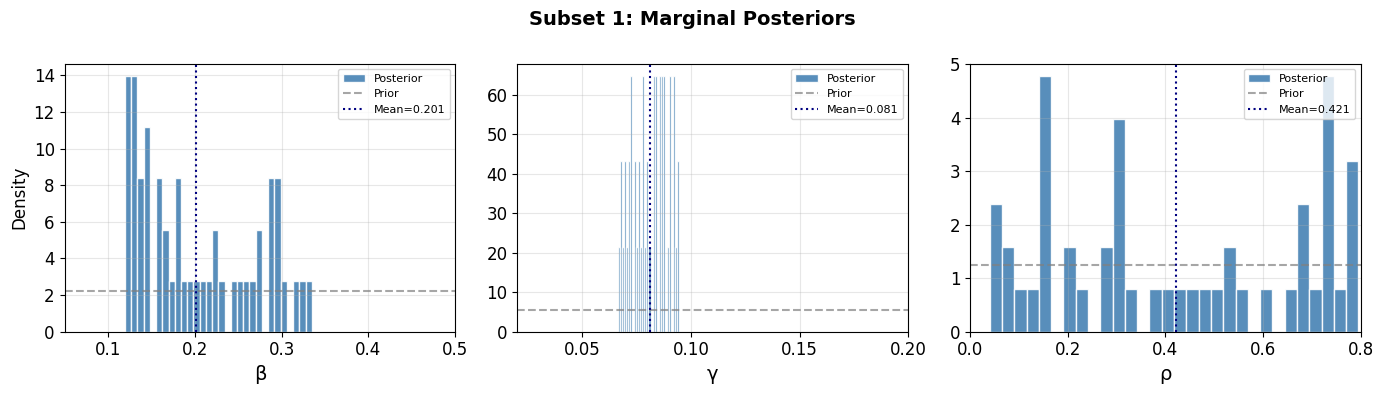

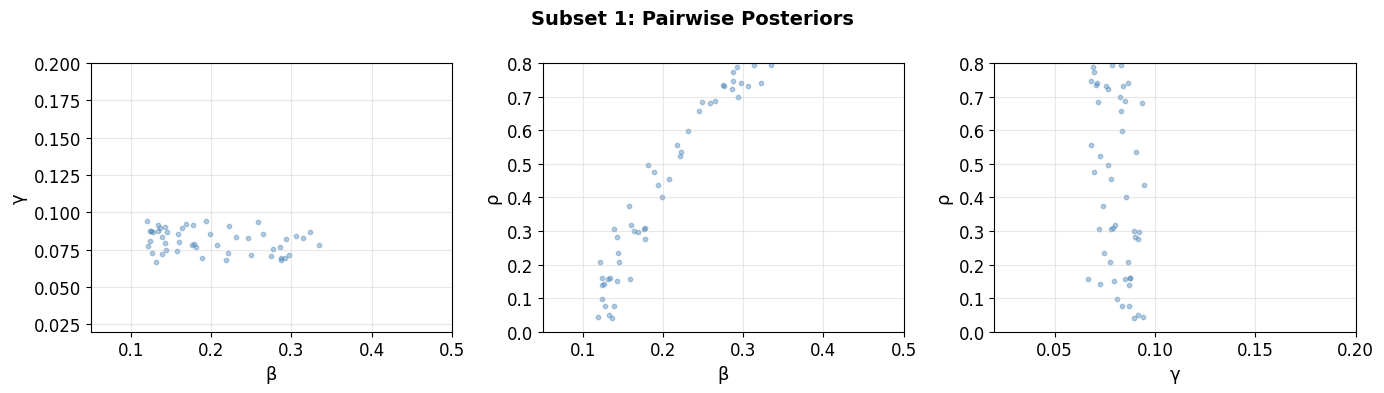

SUBSET 2
-------------------------------------------------------
 Parameter      Mean    Median           95% CI
-------------------------------------------------------
         β    0.1632    0.1654  [0.1220, 0.1962]
         γ    0.0904    0.0918  [0.0594, 0.1180]
         ρ    0.2922    0.2971  [0.2078, 0.3975]


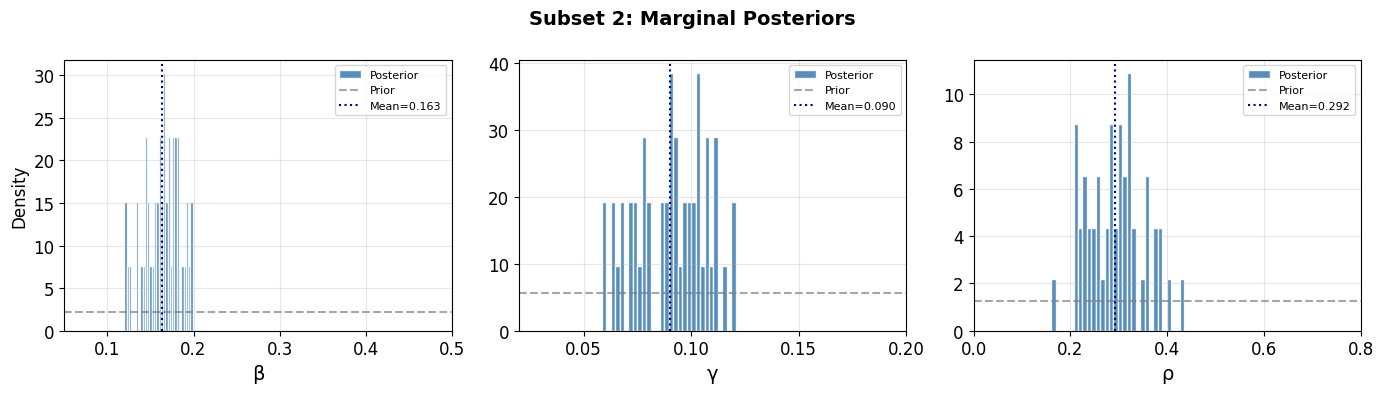

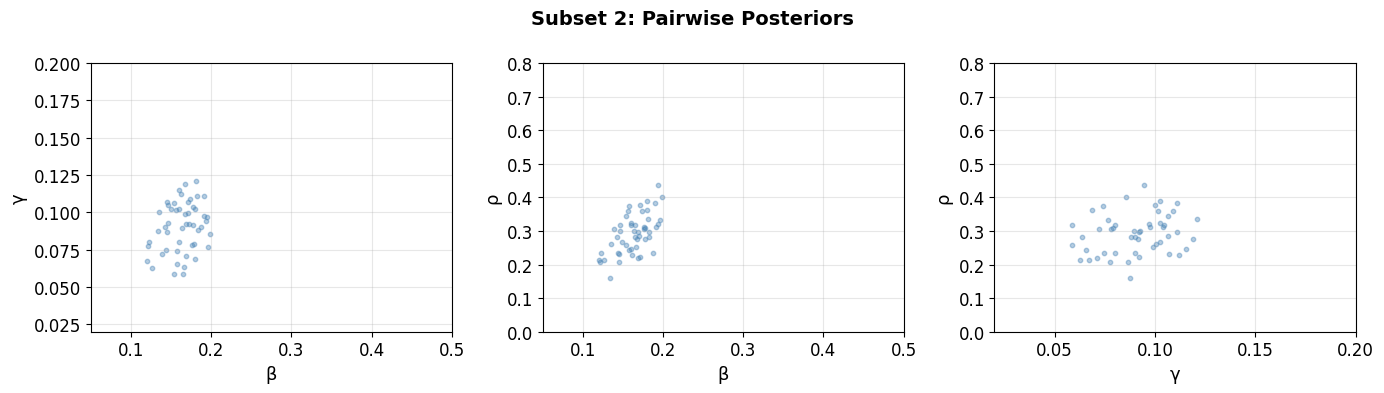

SUBSET 3
-------------------------------------------------------
 Parameter      Mean    Median           95% CI
-------------------------------------------------------
         β    0.1650    0.1663  [0.1220, 0.2007]
         γ    0.0891    0.0909  [0.0584, 0.1180]
         ρ    0.2981    0.2999  [0.2098, 0.3867]


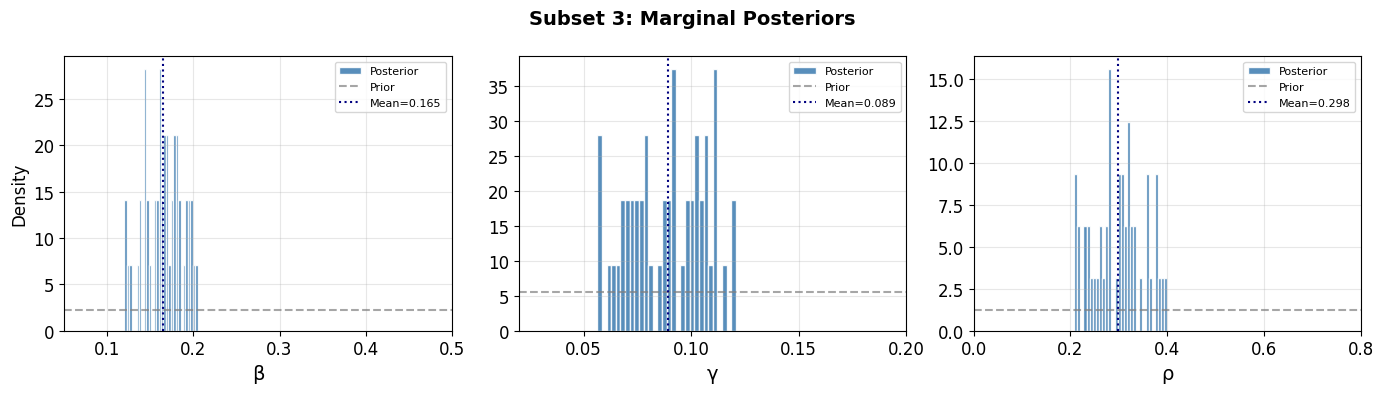

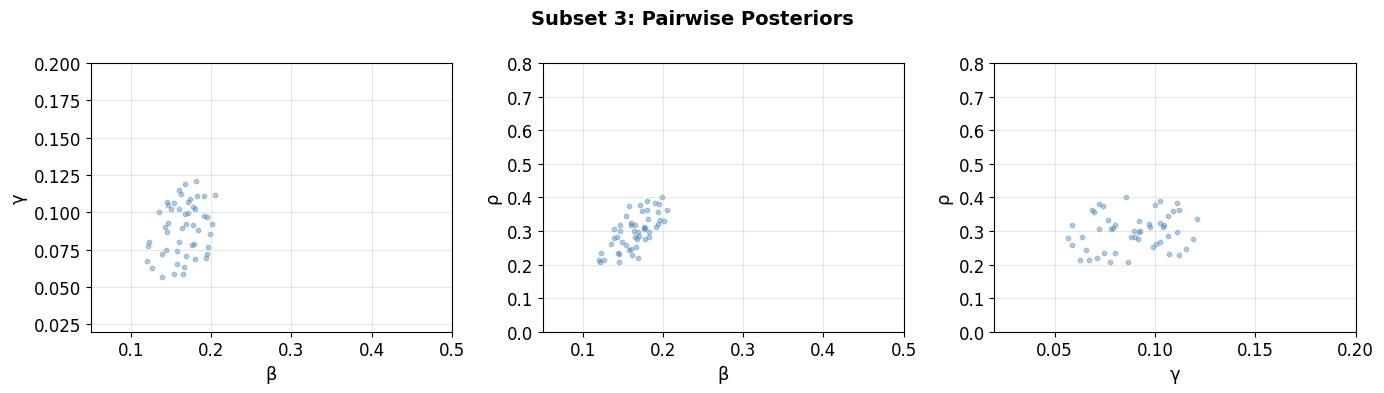

In [ ]:
# Visualize results for each subset
for subset in [1, 2, 3]:
    print(f"SUBSET {subset}")
    print(f"{'-'*55}")
    
    params = results_by_subset[subset]["accepted_params"]
    
    print_posterior_summary(params)
    plot_marginals(params, title=f"Subset {subset}: Marginal Posteriors")
    plot_pairwise(params, title=f"Subset {subset}: Pairwise Posteriors")

## 9. Experiment 2: Effect of Distance Metric

Using Subset 2 (our preferred summary set from Experiment 1), we compare Euclidean vs Manhattan distance.

**Expected:** Qualitatively similar results. Manhattan may be slightly more 
robust if any individual summary has occasional large outliers.



Euclidean
-------------------------------------------------------
 Parameter      Mean    Median           95% CI
-------------------------------------------------------
         β    0.1632    0.1654  [0.1220, 0.1962]
         γ    0.0904    0.0918  [0.0594, 0.1180]
         ρ    0.2922    0.2971  [0.2078, 0.3975]


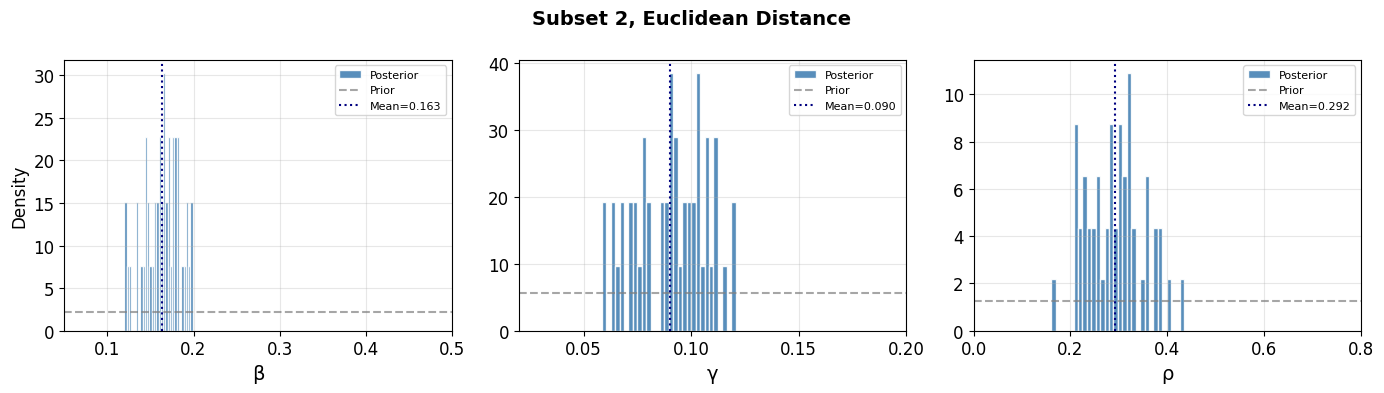


Manhattan
-------------------------------------------------------
 Parameter      Mean    Median           95% CI
-------------------------------------------------------
         β    0.1611    0.1633  [0.1230, 0.1962]
         γ    0.0912    0.0899  [0.0605, 0.1253]
         ρ    0.2897    0.2984  [0.1406, 0.4346]


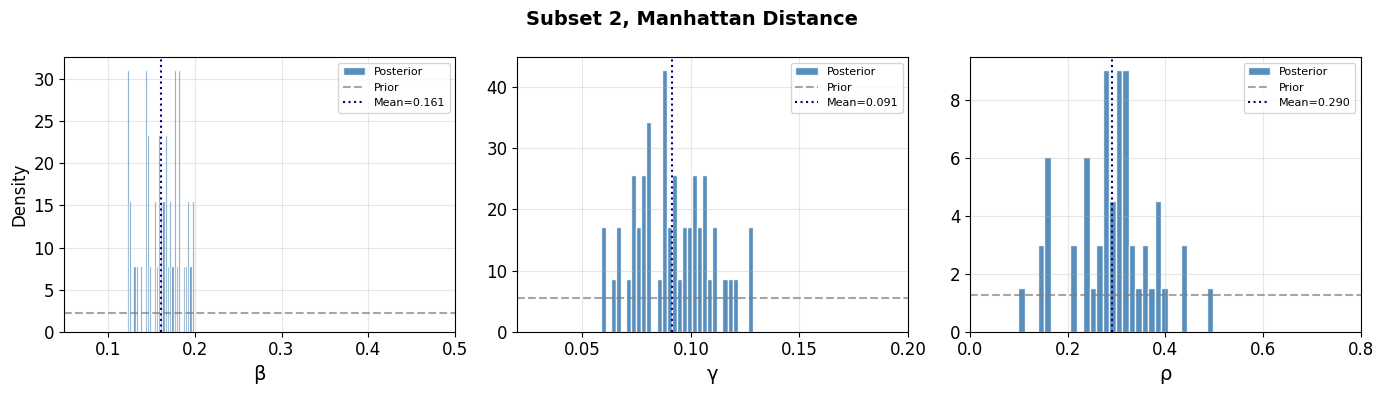

In [ ]:
# Reuse Subset 2 results from Experiment 1 (already computed)
euclidean_results = results_by_subset[2]

# Recompute distances with Manhattan using stored summaries
nm, ns = norm_constants[2]
obs_s = obs_summaries[2]

manhattan_distances = np.array([
    distance_manhattan(s, obs_s, nm, ns) 
    for s in euclidean_results["all_summaries"]
])

# Accept top k%
n_accept = max(1, int(N_SIMS * ACCEPT_PCT / 100))
sorted_idx = np.argsort(manhattan_distances)
accepted_idx = sorted_idx[:n_accept]

results_by_distance = {
    "euclidean": euclidean_results,
    "manhattan": {
        "accepted_params": euclidean_results["all_params"][accepted_idx],
        "accepted_dists": manhattan_distances[accepted_idx],
    },
}

# Visualize
for dist_name in ["euclidean", "manhattan"]:
    params = results_by_distance[dist_name]["accepted_params"]
    print(f"\n{dist_name.title()}")
    print("-" * 55)
    print_posterior_summary(params)
    plot_marginals(params, title=f"Subset 2, {dist_name.title()} Distance")

## 10. Experiment 3: Effect of Acceptance Tolerance

Using Subset 2 and Euclidean distance (established in Experiments 1 and 2), 
we vary the acceptance percentage from 5% to 0.5%. Since rejection ABC 
stores all simulations and their distances, different thresholds can be 
applied to the same run without re-simulating.



Accept 5.0% (250 samples)
-------------------------------------------------------
 Parameter      Mean    Median           95% CI
-------------------------------------------------------
         β    0.1809    0.1813  [0.1173, 0.2459]
         γ    0.0965    0.0972  [0.0546, 0.1415]
         ρ    0.3277    0.3194  [0.1424, 0.5359]

Accept 2.0% (100 samples)
-------------------------------------------------------
 Parameter      Mean    Median           95% CI
-------------------------------------------------------
         β    0.1709    0.1708  [0.1207, 0.2148]
         γ    0.0925    0.0923  [0.0584, 0.1276]
         ρ    0.3060    0.3083  [0.1576, 0.4571]

Accept 1.0% (50 samples)
-------------------------------------------------------
 Parameter      Mean    Median           95% CI
-------------------------------------------------------
         β    0.1632    0.1654  [0.1220, 0.1962]
         γ    0.0904    0.0918  [0.0594, 0.1180]
         ρ    0.2922    0.2971  [0.2078, 0.3975]

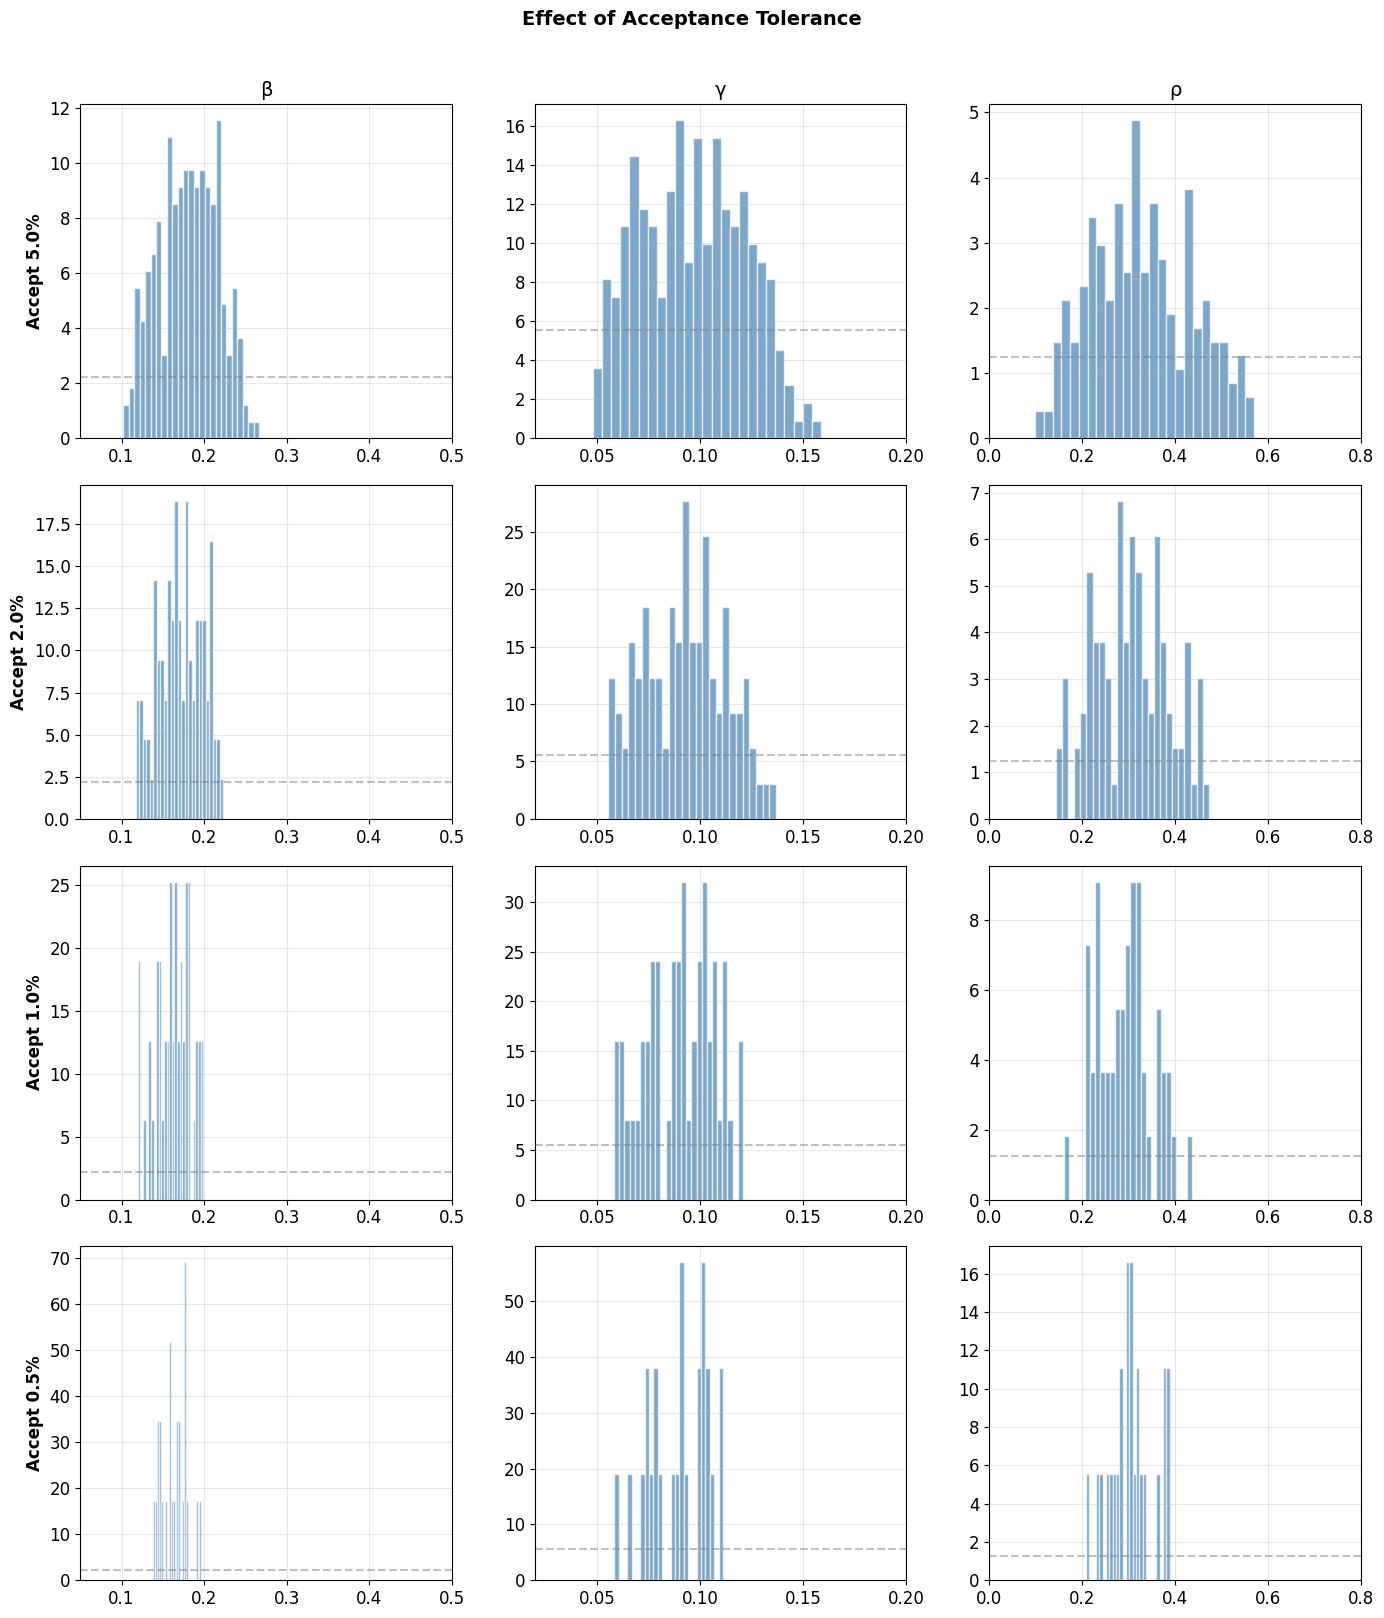

In [ ]:
# Reuse the full run from Experiment 1, Subset 2
full_results = results_by_subset[2]
all_params = full_results["all_params"]
all_distances = full_results["all_distances"]
sorted_idx = np.argsort(all_distances)

accept_pcts = [5.0, 2.0, 1.0, 0.5]

fig, axes = plt.subplots(len(accept_pcts), 3, figsize=(14, 4 * len(accept_pcts)))

for row, pct in enumerate(accept_pcts):
    n_accept = max(1, int(len(all_params) * pct / 100))
    accepted = all_params[sorted_idx[:n_accept]]
    
    print(f"\nAccept {pct}% ({n_accept} samples)")
    print("-" * 55)
    print_posterior_summary(accepted)
    
    for col, (name, bounds) in enumerate(zip(PARAM_NAMES, PRIOR_BOUNDS)):
        ax = axes[row, col]
        ax.hist(accepted[:, col], bins=25, density=True, 
                alpha=0.7, color="steelblue", edgecolor="white")
        
        prior_height = 1.0 / (bounds[1] - bounds[0])
        ax.axhline(prior_height, color="gray", linestyle="--", alpha=0.5)
        
        ax.set_xlim(bounds)
        if col == 0:
            ax.set_ylabel(f"Accept {pct}%", fontsize=12, fontweight="bold")
        if row == 0:
            ax.set_title(name, fontsize=14)

plt.suptitle("Effect of Acceptance Tolerance", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 11. Posterior Predictive Check

Sample parameters from our best posterior (Subset 2, Euclidean, 1% acceptance),
simulate epidemics, and overlay on the observed infection curves.


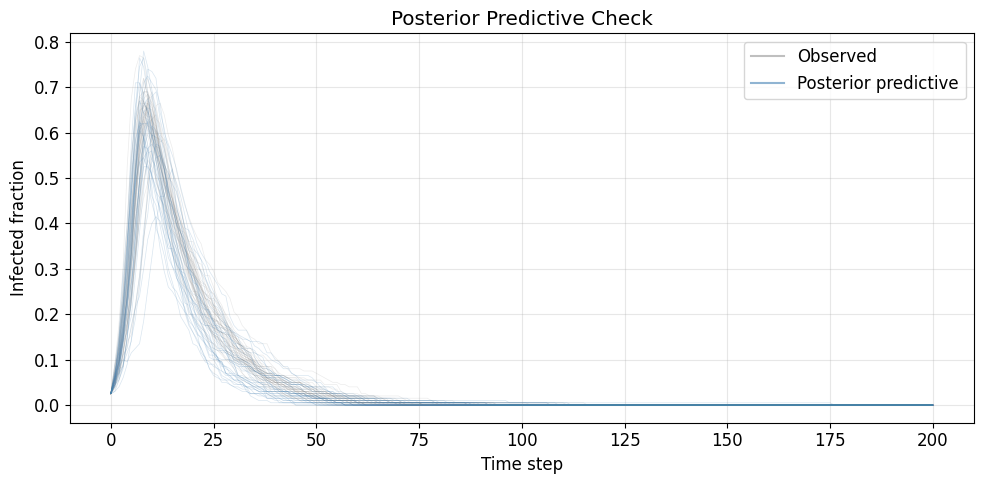

In [ ]:
best_params = results_by_subset[2]["accepted_params"]
plot_posterior_predictive(best_params, obs_infected, n_ppc=30)


## 12. Interface for Advanced Methods

The following are available for building SMC-ABC or other methods:

```python
# Shared functions
from simulator import simulate
draw_from_prior(rng)
compute_summaries_single(inf, rew, deg, subset=2)
compute_summaries_averaged(inf_d, rew_d, deg_d, subset=2)
distance_euclidean(s_sim, s_obs, norm_mean, norm_std)

# Pre-computed data
obs_summaries[2]       # observed target vector
norm_constants[2]      # (norm_mean, norm_std) tuple

# Rejection ABC results (for regression adjustment)
results_by_subset[2]["all_params"]
results_by_subset[2]["all_distances"]
results_by_subset[2]["all_summaries"]
```

In [ ]:
np.savez("rejection_abc_results.npz",
    # Subset results
    sub1_params=results_by_subset[1]["all_params"],
    sub1_dists=results_by_subset[1]["all_distances"],
    sub1_summaries=results_by_subset[1]["all_summaries"],
    sub2_params=results_by_subset[2]["all_params"],
    sub2_dists=results_by_subset[2]["all_distances"],
    sub2_summaries=results_by_subset[2]["all_summaries"],
    sub3_params=results_by_subset[3]["all_params"],
    sub3_dists=results_by_subset[3]["all_distances"],
    sub3_summaries=results_by_subset[3]["all_summaries"],
    # Normalization
    norm_mean=norm_mean_full,
    norm_std=norm_std_full,
    # Observed summaries
    obs_summary_sub1=obs_summaries[1],
    obs_summary_sub2=obs_summaries[2],
    obs_summary_sub3=obs_summaries[3],
)